# Figure 5 & 6 Reproduction — §6.2 Coverage Validation

Reproduces **Figure 5** (Unified-based Upper Bound) and **Figure 6**
(Pattern-based Upper Bounds) from the paper, for all three checkpoints
(49 / 99 / 149) using the 80-query pool built by `3-merge.py`.

**Setup** (paper §6.1 defaults):
- M = 1000 resampling iterations
- δ = 0.1  →  target coverage = 1 − δ = 90%
- K* = (1−δ)/δ = 9  (Lemma 1 minimum sample threshold)
- Split: 50 % calibration / 50 % test, resampled at **query level**

**Data**: `./3-repro-figure5-6/raw_80q_{49,99,149}.json`  
**Output**: `./3-repro-figure5-6/figure5_{49,99,149}.png`,
`figure6_{49,99,149}_{natural,paperdefined}.png`


In [1]:
import json, math, random, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from collections import defaultdict

DATA_DIR = "./3-repro-figure5-6"
CHECKPOINTS = [49, 99, 149]
DELTA = 0.1
M     = 1000
SPLIT = 0.5
K_STAR = (1 - DELTA) / DELTA

# Paper Figure 6 exact patterns
PAPER_TOP3   = ["(NL,NL,IS)", "(NL,HJ,IS)", "(HJ,NL,SS)"]
PAPER_LEAST3 = ["(NL,NL,SS)", "(HJ,SS,SS)", "(HJ,SS,IS)"]

print(f"K* (Lemma 1 threshold) = {K_STAR}")

# ── Algorithm 1 quantile ──────────────────────────────────────────────────────
def getC(sorted_R, delta):
    n = len(sorted_R)
    p = math.ceil((n + 1) * (1 - delta)) - 1
    return sorted_R[min(p, n - 1)]

# ── KDE curve (data in decimal 0‒1, x-axis labels shown as %) ────────────────
def kde_curve(data, x=None):
    if x is None:
        x = np.linspace(0.5, 1.05, 500)
    return x, gaussian_kde(data, bw_method="scott")(x)

def pct_xticks(ax, values=(0.5, 0.6, 0.7, 0.8, 0.9, 1.0)):
    ax.set_xticks(list(values))
    ax.set_xticklabels([f"{int(v*100)}" for v in values])

# ── Query-level resampling (EC_m formula, §6.1) ───────────────────────────────
def coverage_distribution_query(records, M=M, split=SPLIT, delta=DELTA, seed=None):
    if seed is not None:
        random.seed(seed)
    by_query = defaultdict(list)
    for r in records:
        by_query[r["qname"]].append(r["R"])
    qnames = list(by_query.keys())
    n_q = len(qnames)
    k_q = max(1, int(n_q * split))
    ECs = []
    for _ in range(M):
        shuffled_q = qnames.copy()
        random.shuffle(shuffled_q)
        calib_q = shuffled_q[:k_q]
        test_q  = shuffled_q[k_q:]
        calib_R = sorted([r for q in calib_q for r in by_query[q]])
        test_R  = [r for q in test_q  for r in by_query[q]]
        if len(calib_R) == 0 or len(test_R) == 0:
            continue
        C  = getC(calib_R, delta)
        EC = sum(1 for r in test_R if r <= C) / len(test_R)
        ECs.append(EC)
    return np.array(ECs)


K* (Lemma 1 threshold) = 9.0


## Load Data — 80-Query Pool

In [2]:
data = {}
for ckpt in CHECKPOINTS:
    path = os.path.join(DATA_DIR, f"raw_80q_{ckpt}.json")
    recs = json.load(open(path))
    data[ckpt] = recs
    n_q   = len(set(r["qname"]   for r in recs))
    n_pat = len(set(r["pattern"] for r in recs))
    print(f"checkpoint_{ckpt}: {len(recs)} records, {n_q} queries, {n_pat} patterns")


checkpoint_49: 604 records, 80 queries, 19 patterns
checkpoint_99: 604 records, 80 queries, 16 patterns
checkpoint_149: 604 records, 80 queries, 20 patterns


## Figure 5 — Unified-based Upper Bound

One curve per checkpoint. Target: **peak ≥ 90%** (dashed line = 1−δ).


checkpoint_49: peak=90.5%  mean=89.8%  std=5.8%
checkpoint_99: peak=92.8%  mean=89.6%  std=5.6%
checkpoint_149: peak=92.5%  mean=89.7%  std=5.7%


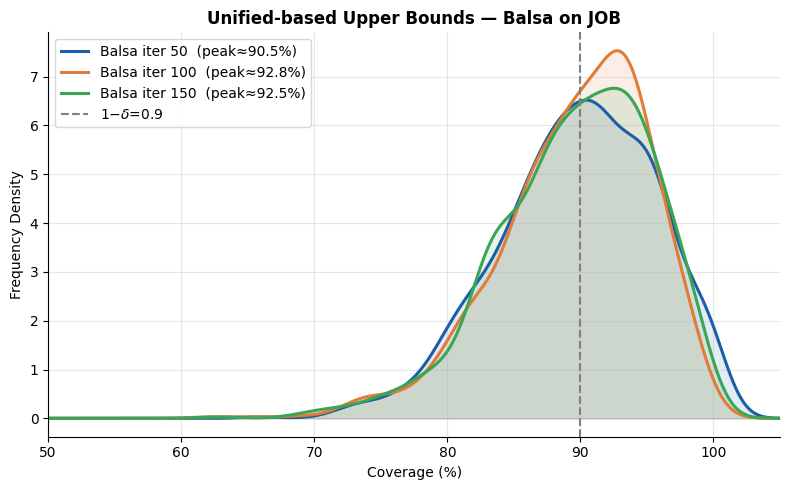

Saved → ./3-repro-figure5-6/figure5_all.png


In [3]:
COLORS = {49: "#1a5fa8", 99: "#e07b39", 149: "#3aa655"}

fig, ax = plt.subplots(figsize=(8, 5))

for ckpt in CHECKPOINTS:
    all_R = [r["R"] for r in data[ckpt]]
    ECs   = coverage_distribution_query(
                [{"qname": r["qname"], "R": r["R"]} for r in data[ckpt]],
                seed=42)
    x, y  = kde_curve(ECs)
    peak  = x[np.argmax(y)]
    ax.plot(x, y, color=COLORS[ckpt], linewidth=2.2,
            label=f"Balsa iter {ckpt+1}  (peak≈{peak*100:.1f}%)")
    ax.fill_between(x, y, alpha=0.12, color=COLORS[ckpt])
    print(f"checkpoint_{ckpt}: peak={peak*100:.1f}%  mean={ECs.mean()*100:.1f}%  std={ECs.std()*100:.1f}%")

ax.axvline(1 - DELTA, color="gray", linestyle="--", linewidth=1.5,
           label=r"1−$\delta$=0.9")
pct_xticks(ax)
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Frequency Density")
ax.set_title("Unified-based Upper Bounds — Balsa on JOB", fontweight="bold")
ax.set_xlim(0.5, 1.05)
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

out = os.path.join(DATA_DIR, "figure5_all.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


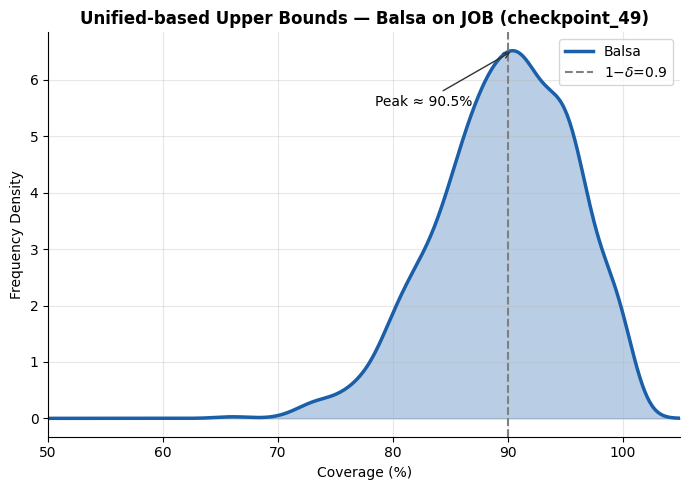

checkpoint_49: peak=90.5% → ./3-repro-figure5-6/figure5_49.png


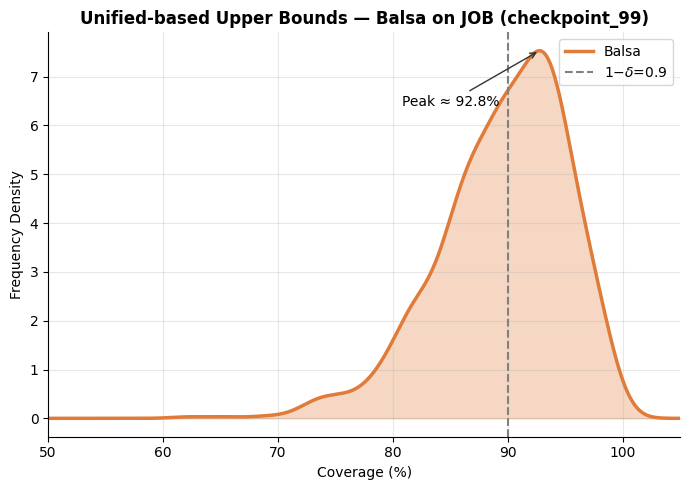

checkpoint_99: peak=92.8% → ./3-repro-figure5-6/figure5_99.png


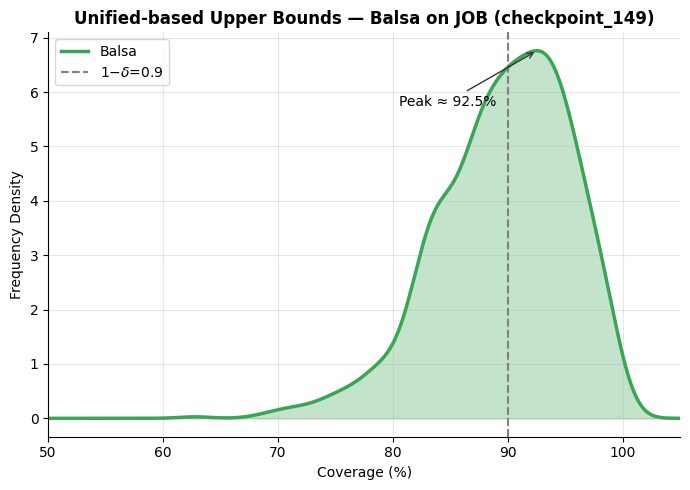

checkpoint_149: peak=92.5% → ./3-repro-figure5-6/figure5_149.png


In [4]:
# Individual Figure 5 per checkpoint
for ckpt in CHECKPOINTS:
    recs  = data[ckpt]
    ECs   = coverage_distribution_query(
                [{"qname": r["qname"], "R": r["R"]} for r in recs], seed=42)
    x, y  = kde_curve(ECs)
    peak  = x[np.argmax(y)]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(x, y, color=COLORS[ckpt], linewidth=2.5, label="Balsa")
    ax.fill_between(x, y, alpha=0.3, color=COLORS[ckpt])
    ax.axvline(1 - DELTA, color="gray", linestyle="--", linewidth=1.5,
               label=r"1−$\delta$=0.9")
    ax.annotate(f"Peak ≈ {peak*100:.1f}%", xy=(peak, y.max()),
                xytext=(peak - 0.12, y.max() * 0.85),
                arrowprops=dict(arrowstyle="->", color="#333"))
    pct_xticks(ax)
    ax.set_xlabel("Coverage (%)")
    ax.set_ylabel("Frequency Density")
    ax.set_title(f"Unified-based Upper Bounds — Balsa on JOB (checkpoint_{ckpt})",
                 fontweight="bold")
    ax.set_xlim(0.5, 1.05)
    ax.legend(); ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    out = os.path.join(DATA_DIR, f"figure5_{ckpt}.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"checkpoint_{ckpt}: peak={peak*100:.1f}% → {out}")


## Figure 6 — Pattern-based Upper Bounds

In [5]:
def get_natural_groups(records):
    by_pat = defaultdict(list)
    for r in records:
        by_pat[r["pattern"]].append(r)
    sorted_pats = sorted(by_pat.items(), key=lambda kv: -len(kv[1]))
    top3   = sorted_pats[:3]
    eligible = [(p, rs) for p, rs in sorted_pats if len(rs) >= K_STAR]
    least3 = sorted(eligible, key=lambda kv: len(kv[1]))[:3]
    return top3, least3

def get_paper_groups(records):
    by_pat = defaultdict(list)
    for r in records:
        by_pat[r["pattern"]].append(r)
    top3   = [(p, by_pat.get(p, [])) for p in PAPER_TOP3]
    least3 = [(p, by_pat.get(p, [])) for p in PAPER_LEAST3]
    return top3, least3

def plot_pattern_group(pattern_group, title, ax, x_start=0.3, seed=123):
    Cs = []
    xticks = [v for v in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] if v >= x_start]
    for pat, group_recs in pattern_group:
        if not group_recs:
            print(f"  [WARNING] {pat}: not found in data, skipping")
            continue
        n_q = len(set(r["qname"] for r in group_recs))
        if n_q < 2:
            print(f"  [SKIP] {pat}: only {n_q} unique query")
            continue
        ECs = coverage_distribution_query(
            [{"qname": r["qname"], "R": r["R"]} for r in group_recs], seed=seed)
        x, y = kde_curve(ECs, x=np.linspace(x_start, 1.05, 500))
        ax.plot(x, y, linewidth=2, label=f"{pat} (K={len(group_recs)})")
        ax.fill_between(x, y, alpha=0.12)
        C = getC(sorted([r["R"] for r in group_recs]), DELTA)
        Cs.append((pat, len(group_recs), C))

    ax.axvline(1 - DELTA, color="gray", linestyle="--", linewidth=1.5,
               label=r"1−$\delta$=0.9")
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(v*100)}" for v in xticks])
    ax.set_xlabel("Coverage (%)")
    ax.set_ylabel("Frequency Density")
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(x_start, 1.05)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    return Cs

def print_results(label, Cs_top3, Cs_least3):
    print(f"\n  === {label} ===")
    print("  Top-3:")
    for pat, k, c in Cs_top3:
        print(f"    {pat:14s}  K={k:4d}  C={c:10.1f}")
    if Cs_top3:
        print(f"    mean(C) top-3 = {np.mean([c for _,_,c in Cs_top3]):.1f}"
              f"  (paper claims ≈3056)")
    print("  Least-3:")
    for pat, k, c in Cs_least3:
        print(f"    {pat:14s}  K={k:4d}  C={c:10.1f}")



  Figure 6 — checkpoint_49


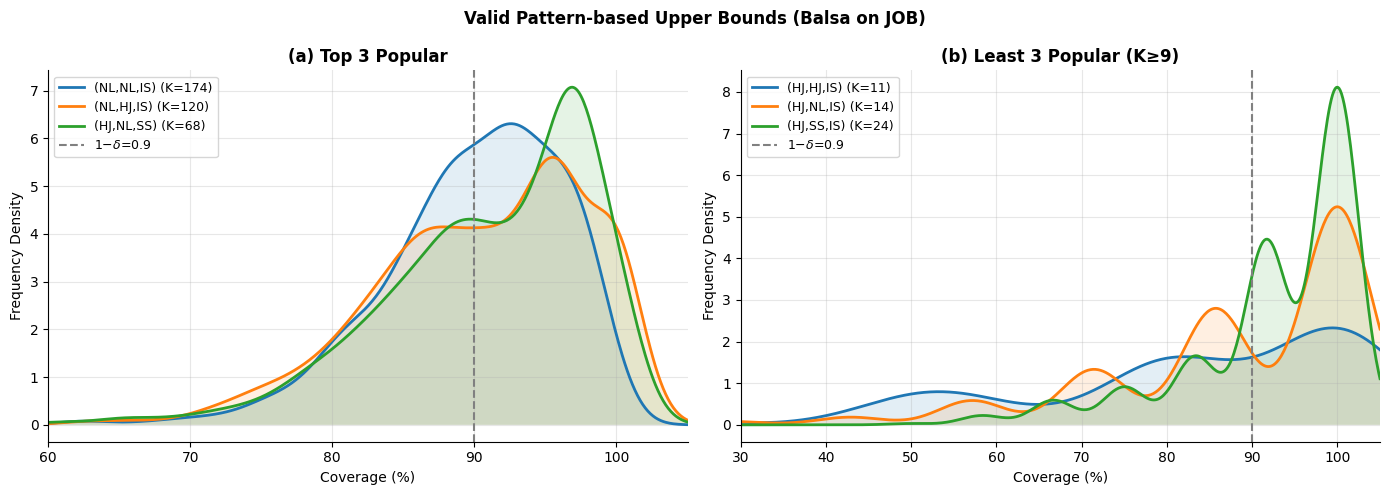


  === checkpoint_49 — Natural ===
  Top-3:
    (NL,NL,IS)      K= 174  C=    4114.8
    (NL,HJ,IS)      K= 120  C=    8737.2
    (HJ,NL,SS)      K=  68  C=    5264.5
    mean(C) top-3 = 6038.8  (paper claims ≈3056)
  Least-3:
    (HJ,HJ,IS)      K=  11  C=  168731.8
    (HJ,NL,IS)      K=  14  C=  621867.8
    (HJ,SS,IS)      K=  24  C=    3651.4
  Saved → ./3-repro-figure5-6/figure6_49_natural.png


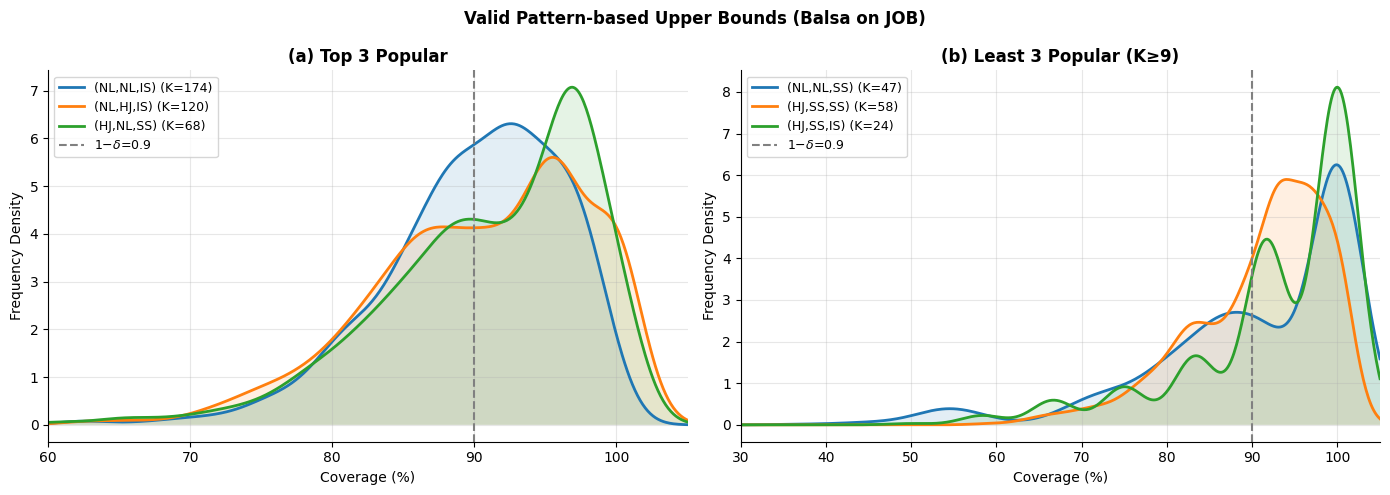


  === checkpoint_49 — Paper-defined ===
  Top-3:
    (NL,NL,IS)      K= 174  C=    4114.8
    (NL,HJ,IS)      K= 120  C=    8737.2
    (HJ,NL,SS)      K=  68  C=    5264.5
    mean(C) top-3 = 6038.8  (paper claims ≈3056)
  Least-3:
    (NL,NL,SS)      K=  47  C=    3944.8
    (HJ,SS,SS)      K=  58  C=    1170.7
    (HJ,SS,IS)      K=  24  C=    3651.4
  Saved → ./3-repro-figure5-6/figure6_49_paperdefined.png

  Figure 6 — checkpoint_99


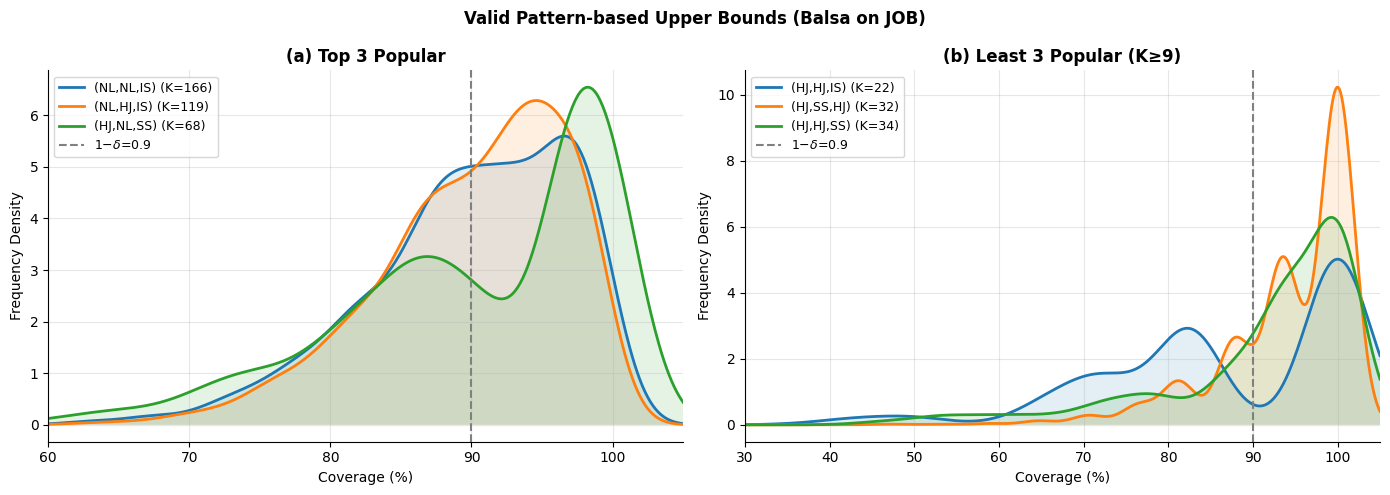


  === checkpoint_99 — Natural ===
  Top-3:
    (NL,NL,IS)      K= 166  C=    4068.0
    (NL,HJ,IS)      K= 119  C=    4204.6
    (HJ,NL,SS)      K=  68  C=    3587.9
    mean(C) top-3 = 3953.5  (paper claims ≈3056)
  Least-3:
    (HJ,HJ,IS)      K=  22  C=   12344.2
    (HJ,SS,HJ)      K=  32  C=    1916.4
    (HJ,HJ,SS)      K=  34  C=    4409.4
  Saved → ./3-repro-figure5-6/figure6_99_natural.png


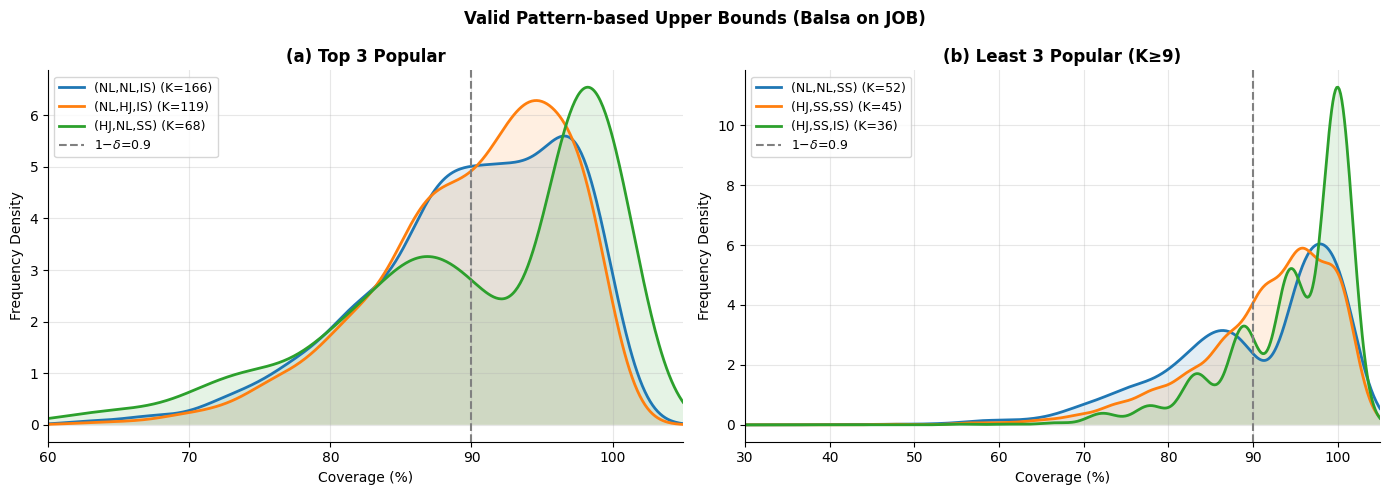


  === checkpoint_99 — Paper-defined ===
  Top-3:
    (NL,NL,IS)      K= 166  C=    4068.0
    (NL,HJ,IS)      K= 119  C=    4204.6
    (HJ,NL,SS)      K=  68  C=    3587.9
    mean(C) top-3 = 3953.5  (paper claims ≈3056)
  Least-3:
    (NL,NL,SS)      K=  52  C=    4828.2
    (HJ,SS,SS)      K=  45  C=    1543.1
    (HJ,SS,IS)      K=  36  C=    3016.3
  Saved → ./3-repro-figure5-6/figure6_99_paperdefined.png

  Figure 6 — checkpoint_149


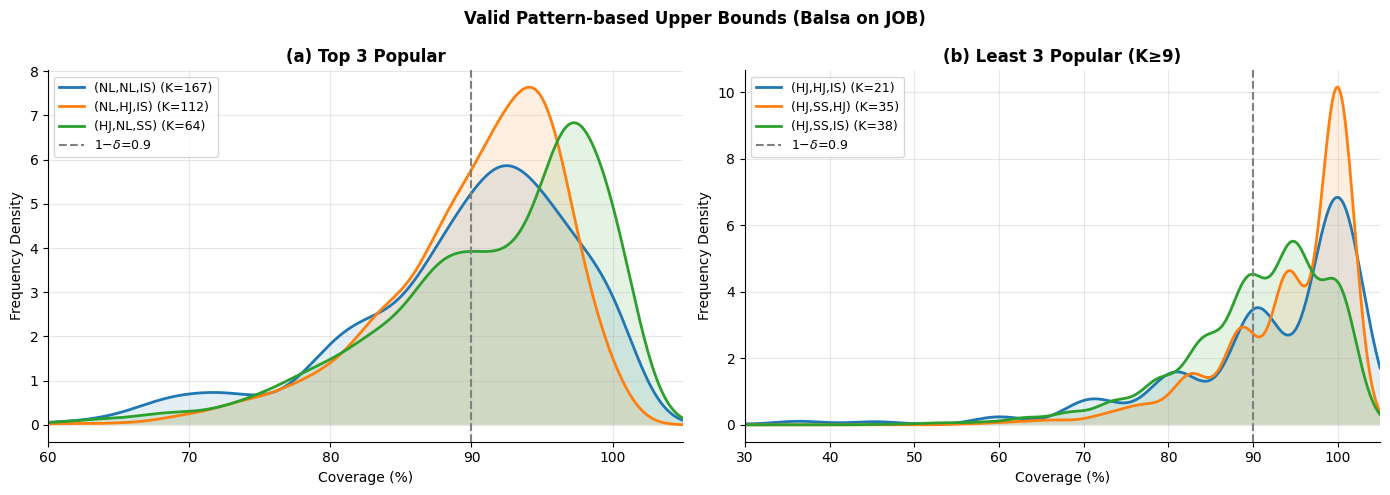


  === checkpoint_149 — Natural ===
  Top-3:
    (NL,NL,IS)      K= 167  C=    4080.7
    (NL,HJ,IS)      K= 112  C=    3353.9
    (HJ,NL,SS)      K=  64  C=    3335.2
    mean(C) top-3 = 3589.9  (paper claims ≈3056)
  Least-3:
    (HJ,HJ,IS)      K=  21  C=    3379.2
    (HJ,SS,HJ)      K=  35  C=    2544.1
    (HJ,SS,IS)      K=  38  C=    2224.0
  Saved → ./3-repro-figure5-6/figure6_149_natural.png


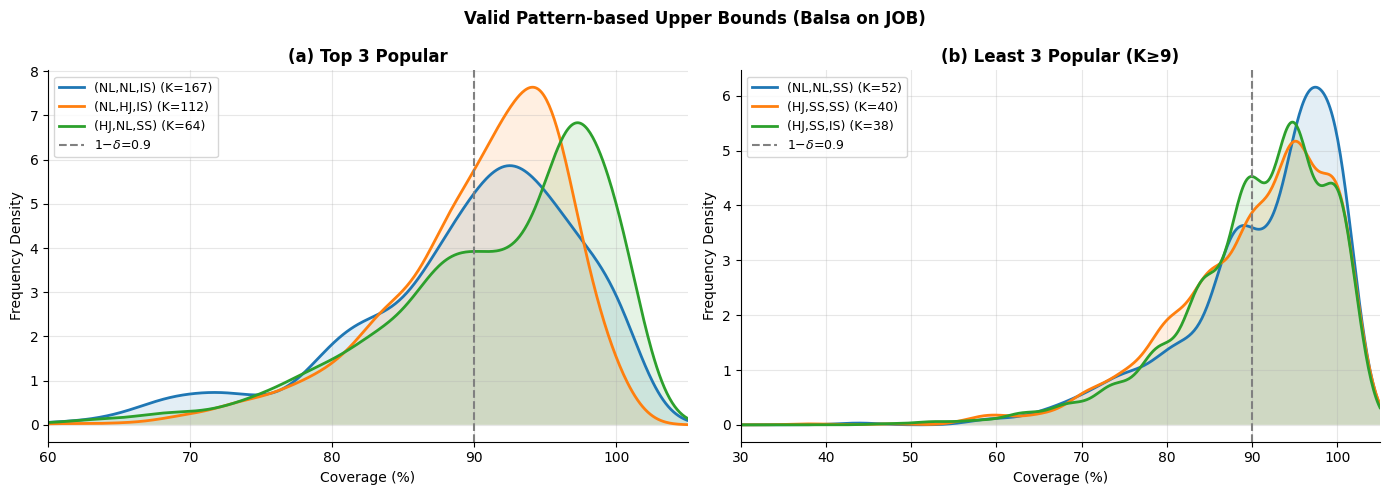


  === checkpoint_149 — Paper-defined ===
  Top-3:
    (NL,NL,IS)      K= 167  C=    4080.7
    (NL,HJ,IS)      K= 112  C=    3353.9
    (HJ,NL,SS)      K=  64  C=    3335.2
    mean(C) top-3 = 3589.9  (paper claims ≈3056)
  Least-3:
    (NL,NL,SS)      K=  52  C=    6057.3
    (HJ,SS,SS)      K=  40  C=    1100.5
    (HJ,SS,IS)      K=  38  C=    2224.0
  Saved → ./3-repro-figure5-6/figure6_149_paperdefined.png


In [6]:
for ckpt in CHECKPOINTS:
    recs = data[ckpt]
    print(f"\n{'='*55}")
    print(f"  Figure 6 — checkpoint_{ckpt}")
    print(f"{'='*55}")

    for variant, get_groups in [("natural", get_natural_groups),
                                 ("paperdefined", get_paper_groups)]:
        top3, least3 = get_groups(recs)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        Cs_top3   = plot_pattern_group(top3,   "(a) Top 3 Popular",
                                       axes[0], x_start=0.6)
        Cs_least3 = plot_pattern_group(least3,
                                       f"(b) Least 3 Popular (K≥{K_STAR:.0f})",
                                       axes[1], x_start=0.3)

        label = f"checkpoint_{ckpt} — {'Natural' if variant=='natural' else 'Paper-defined'}"
        plt.suptitle(f"Valid Pattern-based Upper Bounds (Balsa on JOB)",
                     fontweight="bold")
        plt.tight_layout()

        out = os.path.join(DATA_DIR, f"figure6_{ckpt}_{variant}.png")
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print_results(label, Cs_top3, Cs_least3)
        print(f"  Saved → {out}")
